In [152]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import sklearn as sk
import numpy as np
from sklearn.preprocessing import StandardScaler

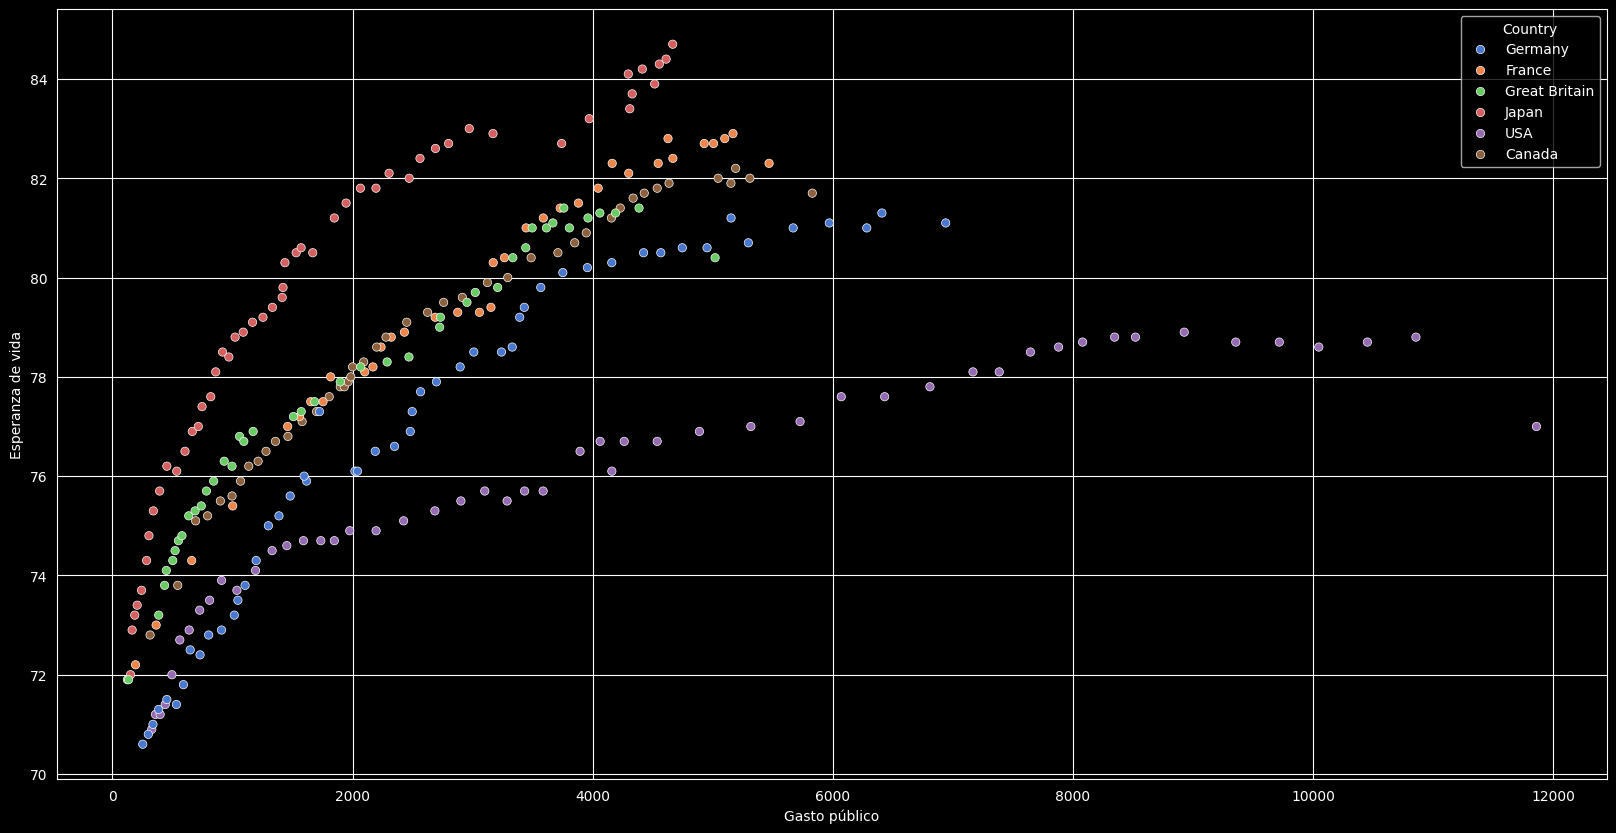

In [153]:
data_raw = sb.load_dataset('healthexp')

plt.figure(figsize=(20,10))

sb.scatterplot(data_raw, x = 'Spending_USD', y = 'Life_Expectancy', hue='Country', palette='muted')
plt.xlabel('Gasto público')
plt.ylabel('Esperanza de vida')
plt.show()


Con pandas se pueden seleccionar los elementos del dataset que cumplen la condición deseada, las expresiones que comparan una columna del dataset con un valor devuelven una mascara que se puede utilizar para obtener el subset buscado



In [154]:
training_data_raw = data_raw[data_raw['Year'] < 2008]
validating_data_raw = data_raw[data_raw['Year'] >= 2008]
validating_data_raw = validating_data_raw[validating_data_raw['Year'] <= 2015]
testing_data_raw = data_raw[data_raw['Year'] > 2015]

**Preprocesamiento**


In [155]:
enc = sk.preprocessing.OneHotEncoder(sparse_output = False)

country_encoded = enc.fit_transform(data_raw[["Country"]])

print(country_encoded)
print(country_encoded.shape)

[[0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 ...
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]]
(274, 6)


Como se puede ver en el arreglo obtenido en base a la codificacion, el OneHotEncoder asigna arreglos de dimensión 6 (ya que hay 6 paises en el dataset) con un uno en la posicion asignada a cada pais. Como no se puede establecer un orden entre los paises se utiliza el metodo One-Hot, que asigna simbolos arbitrarios a cada categoria.  Este tipo de codificacion resulta en simbolos que se encuentran a la misma distancia unos de otros.

In [156]:
poly = sk.preprocessing.PolynomialFeatures(degree = 3)
poly.fit(data_raw[["Spending_USD"]])

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [157]:
transformer = sk.compose.ColumnTransformer([
    ("country", enc, ["Country"]),
    ("poly", poly, ["Spending_USD"]),
])

full_preprocessing = sk.pipeline.Pipeline([
    ("preprocessor", transformer),
    ("scaler", StandardScaler())
])

out_norm = full_preprocessing.fit_transform(data_raw)

print(out_norm)
print(out_norm.shape)

[[-0.43738352 -0.38267939  2.11660105 ... -1.15796809 -0.62979714
  -0.39230552]
 [-0.43738352  2.61315354 -0.47245559 ... -1.18543039 -0.63114268
  -0.39235211]
 [-0.43738352 -0.38267939 -0.47245559 ... -1.21653589 -0.63222671
  -0.39237906]
 ...
 [-0.43738352 -0.38267939 -0.47245559 ...  1.01754064  0.63431711
   0.26426577]
 [-0.43738352 -0.38267939 -0.47245559 ...  0.85639498  0.46228074
   0.13520198]
 [-0.43738352 -0.38267939 -0.47245559 ...  4.1397201   6.44339639
   8.27178667]]
(274, 10)


Para el preprocesamiento se codificaron las clasificaiones de los datos de forma One-Hot, luego se generó el mapa polinomico del orden deseado y por ultimo se combinaron ambas operaciones para sumar una normalizacion de parametros a traves de un pipeline.

**Regresion Polinomica**


In [158]:
pipeline = sk.pipeline.Pipeline([
    ("preprocessor", transformer),
    ("scaler", StandardScaler()),
    ("regressor", sk.linear_model.LinearRegression())
])

In [159]:
sk.set_config(display='diagram')
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('country', ...), ('poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

La cantidad de parametros coincidirá con la cantidad de columnas del dataset obtenido tras el preprocesamiento, que cuenta con 6 columnas de la codificación One-Hot y como se trata de un modelo basado en un mapa polinomico de orden 3 con 1 variable, lo que resulta en un mapa polinomico con $\binom{3}{1} + 1 = 3 + 1$ columnas (el +1 nace de incluir el bias en el mapa), la cantidad de columnas total es 10, entonces el modelo contará con 10 parámetros.

In [160]:
pipeline.fit(training_data_raw, training_data_raw['Life_Expectancy'])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('country', ...), ('poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [161]:
out_train_pred = pipeline.predict(training_data_raw)
out_val_pred = pipeline.predict(validating_data_raw)

In [162]:
mse_train = sk.metrics.mean_squared_error(training_data_raw['Life_Expectancy'], out_train_pred)
mse_val = sk.metrics.mean_squared_error(validating_data_raw['Life_Expectancy'], out_val_pred)

print(mse_train)
print(mse_val)

0.426455330406819
5.3686508154240675


In [163]:
print(out_train_pred.shape)
print(out_val_pred.shape)

(196,)
(48,)


In [164]:
training_data_raw["Life_Expectancy_pred"] = out_train_pred
validating_data_raw["Life_Expectancy_pred"] = out_val_pred

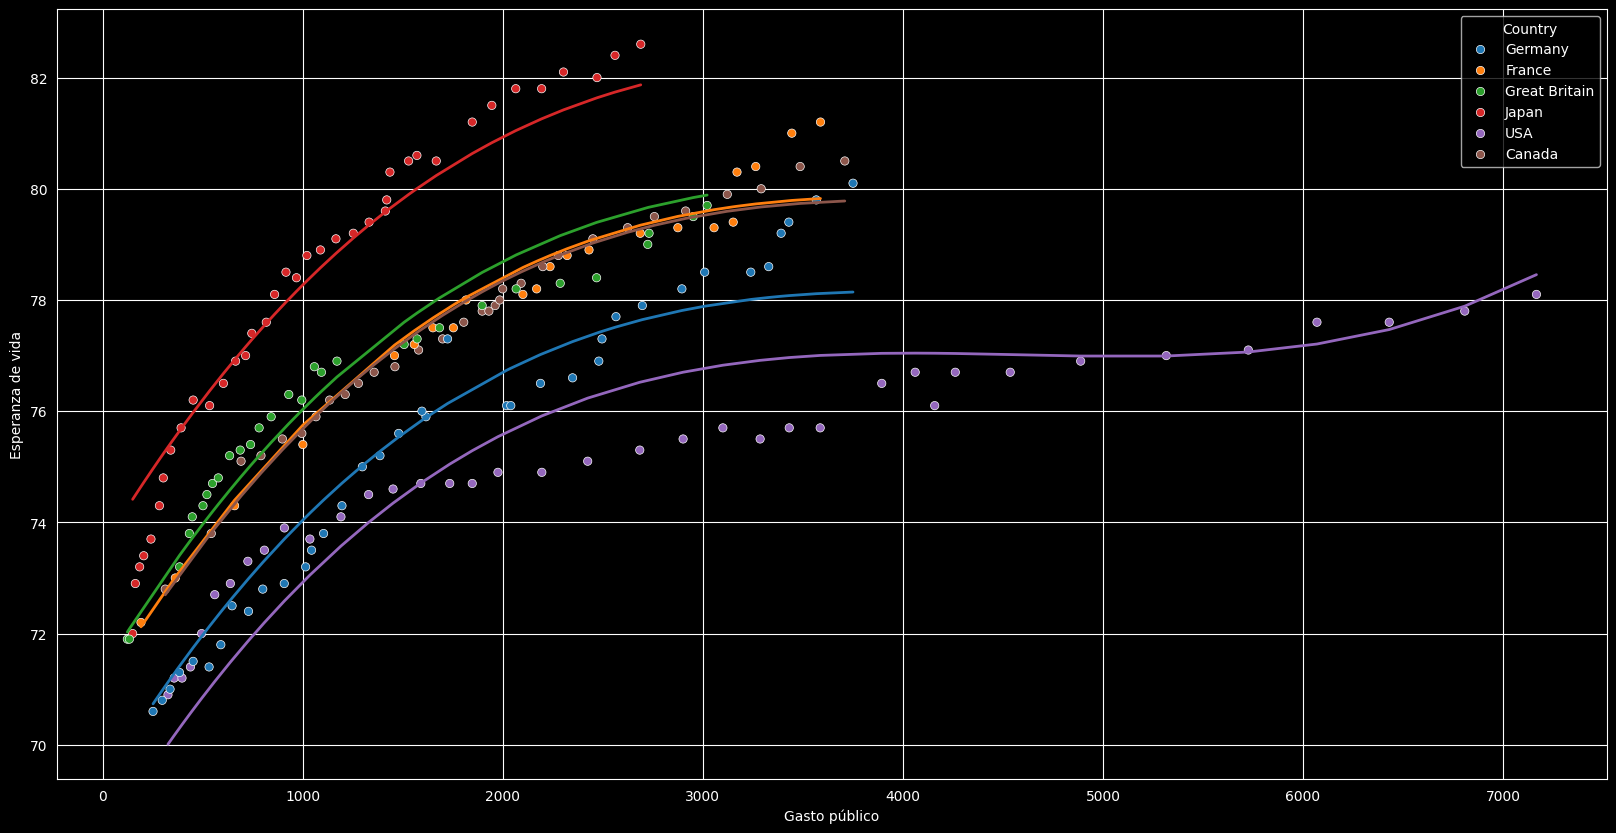

In [165]:
plt.figure(figsize=(20,10))

palette = sb.color_palette("tab10", n_colors=data_raw["Country"].nunique())

sb.scatterplot(training_data_raw, x = 'Spending_USD', y = 'Life_Expectancy', hue='Country', palette=palette)
sb.lineplot(training_data_raw, x = 'Spending_USD', y = 'Life_Expectancy_pred', hue='Country', legend=False, linewidth = 2, palette=palette)
plt.xlabel('Gasto público')
plt.ylabel('Esperanza de vida')
plt.show()

Se obtuvo un ecm de entrenamiento de 0.43 y uno de validación de 5.37. La próxima sección se centrará en disminuir el error de validación.

**Regularización**

In [167]:
pipeline = sk.pipeline.Pipeline([
    ("preprocessor", transformer),
    ("scaler", StandardScaler()),
    ("regressor", sk.linear_model.Ridge(alpha = 0.1))
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('country', ...), ('poly', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

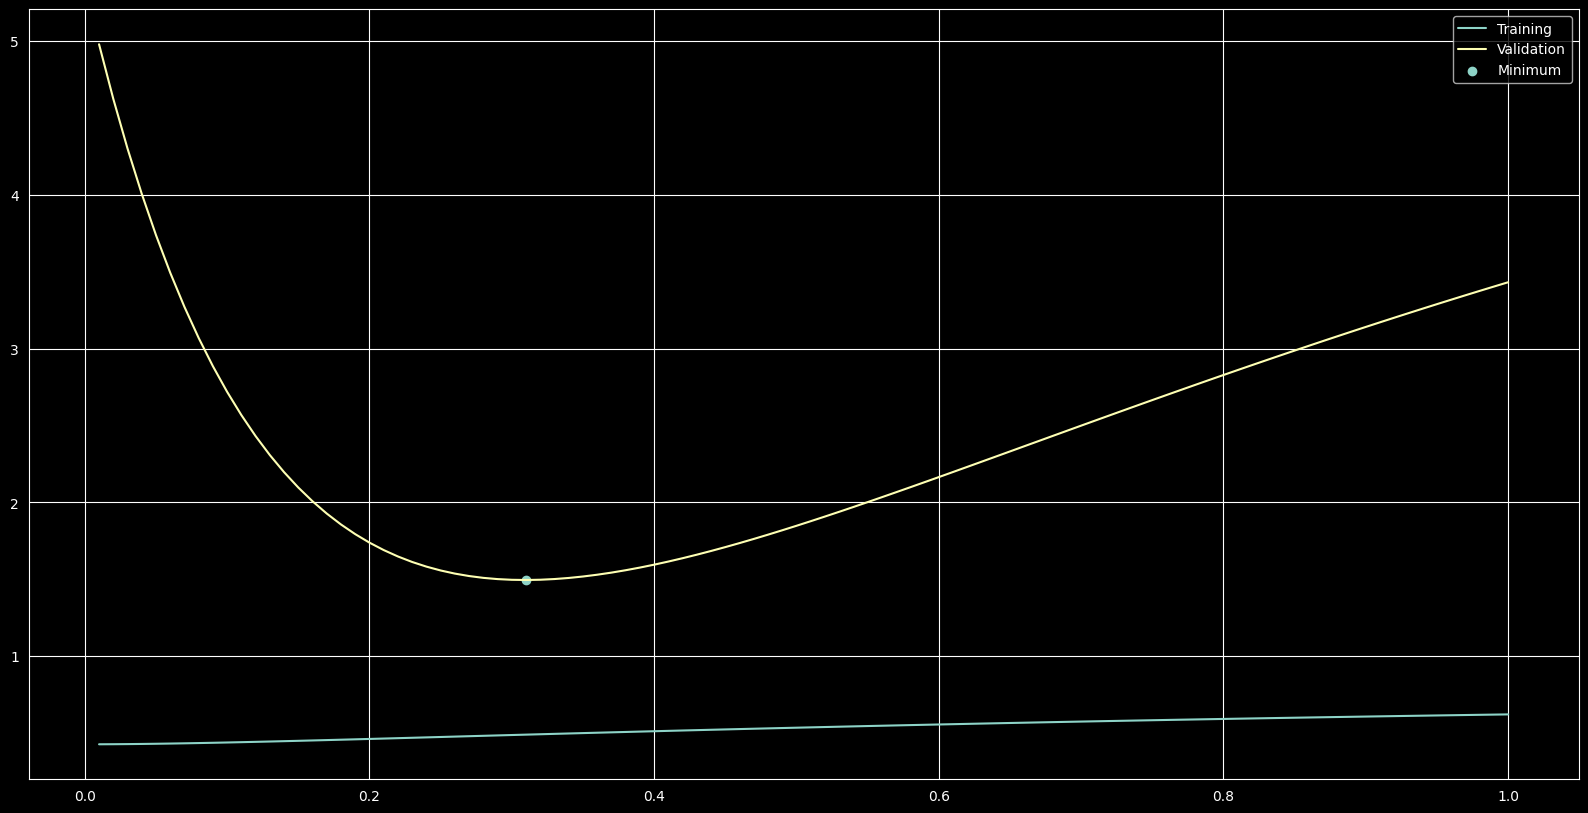

El lambda que minimiza el error es: 0.3100000000000001
El minimo error cuadratico medio de validacion es: 1.4951437955132512


In [168]:
mse_list = np.empty([3,100])
lamb = 1 / 100
for i in range(100):
    pipeline = sk.pipeline.Pipeline([
        ("preprocessor", transformer),
        ("scaler", StandardScaler()),
        ("regressor", sk.linear_model.Ridge(alpha = lamb))
    ])

    pipeline.fit(training_data_raw, training_data_raw['Life_Expectancy'])
    out_train_pred = pipeline.predict(training_data_raw)
    out_val_pred = pipeline.predict(validating_data_raw)

    mse_train = sk.metrics.mean_squared_error(training_data_raw['Life_Expectancy'], out_train_pred)
    mse_val = sk.metrics.mean_squared_error(validating_data_raw['Life_Expectancy'], out_val_pred)
    mse_list[0,i] = lamb
    mse_list[1,i] = mse_train
    mse_list[2,i] = mse_val
    lamb += 1 / 100



min_val_mse_lamb_index = mse_list[2].argmin()

plt.figure(figsize=(20,10))

plt.plot(mse_list[0], mse_list[1], label="Training")
plt.plot(mse_list[0], mse_list[2], label="Validation")
plt.scatter(mse_list[0, min_val_mse_lamb_index], mse_list[2, min_val_mse_lamb_index], label="Minimum")
plt.legend()

plt.show()


print(f"El lambda que minimiza el error es: {mse_list[0, min_val_mse_lamb_index]}")
print(f"El minimo error cuadratico medio de validacion es: {mse_list[2, min_val_mse_lamb_index]}")


In [169]:
pipeline = sk.pipeline.Pipeline([
        ("preprocessor", transformer),
        ("scaler", StandardScaler()),
        ("regressor", sk.linear_model.Ridge(alpha = mse_list[0, min_val_mse_lamb_index]))
    ])
pipeline.fit(training_data_raw, training_data_raw['Life_Expectancy'])

out_test_pred = pipeline.predict(testing_data_raw)
mse_test = sk.metrics.mean_squared_error(testing_data_raw['Life_Expectancy'], out_test_pred)
print(f"El error cuadrático medio de testeo obtenido es: {mse_test}")

out_full_pred = pipeline.predict(data_raw)

data_raw["Life_Expectancy_pred"] = out_full_pred

El error cuadrático medio de testeo obtenido es: 5.462337580080913


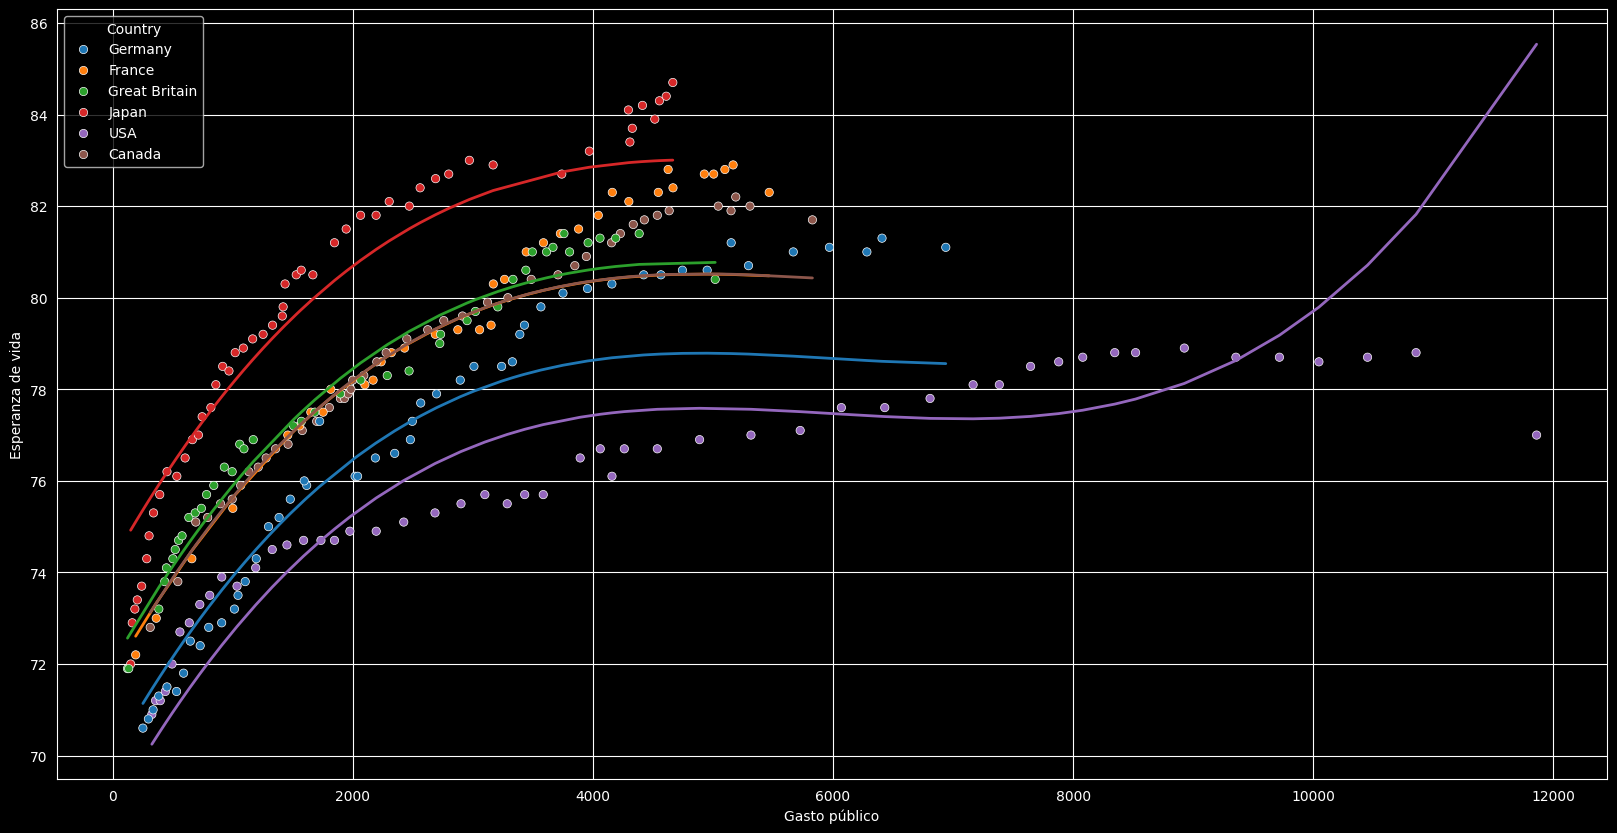

In [170]:
plt.figure(figsize=(20,10))

palette = sb.color_palette("tab10", n_colors=data_raw["Country"].nunique())

sb.scatterplot(data_raw, x = 'Spending_USD', y = 'Life_Expectancy', hue='Country', palette=palette)
sb.lineplot(data_raw, x = 'Spending_USD', y = 'Life_Expectancy_pred', hue='Country', legend=False, linewidth = 2, palette=palette)
plt.xlabel('Gasto público')
plt.ylabel('Esperanza de vida')
plt.show()

Se bajó considerablemente el error de validación respecto a la sección anterior, sin embargo el error de testeo resulta considerablemente mayor a los de entrenamiento y validación. En el gráfico se puede observar como el ajuste de las curvas resulta peor a grandes valores de gasto publico.

**Teoria**

El objetivo es minimizar la funcion costo $J(\mathbf{w})$, la cual está expresada de la siguiente forma:

$$J = \frac{1}{n_{tr}}∑(y_i-\hat{y_i})^2+λ\|w\|^2$$

Luego, como $\hat{y_i} = \mathbf{w}^T\mathbf{X_i} + b$ y además reemplazando la sumatoria por la expresión matricial, la funcion resulta:

$$J = \frac{1}{n_{tr}}(y-Xw-b\mathbf{1})^T(y-Xw-b\mathbf{1})+ λw^Tw$$

Donde $\mathbf{1}$ es un vector de 1s de dimension $n_{tr}$

Para simplificar el desarrollo, se definen nuevas matrices $\mathbf{W}$ y $\mathbf{X}$ de la siguiente forma

$$\mathbf{W} = \begin{bmatrix}
b \\
w
\end{bmatrix}$$

$$\mathbf{X} = \begin{bmatrix}
1 & X_1 \\
1 & X_2 \\
\vdots & \vdots \\
1 & X_n
\end{bmatrix}$$

Luego, como resulta $\hat{y_i} = \mathbf{W}^T \mathbf{X}$ se puede reescribir el primer termino de la funcion anterior sin problemas, para que el segundo termino se mantenga igual con la redefinicion de $\mathbf{W}$ resulta necesario definir una matriz $\mathbf{D}$ de la siguiente forma:

$$\mathbf{D} = \begin{bmatrix}
0 & [0] \\
[0] & [1]
\end{bmatrix}$$

Donde $[1]$ es una matriz cuadrada de dimension $n_{tr}$ y los $[0]$ son vectores fila/columna de la misma dimension.

De esta forma, la funcion costo queda definida como:

$$J = \frac{1}{n_{tr}}(\mathbf{Y}-\mathbf{W}^T\mathbf{X})^T(\mathbf{Y}-\mathbf{W}^T\mathbf{X})+ \lambda\mathbf{W}^T\mathbf{D}\mathbf{W}$$

Luego, desarrollando el producto del primer termino se llega a la expresion:

$$J = \frac{1}{n_{tr}} \left[ \mathbf{Y}^T\mathbf{Y} - 2\mathbf{X}^T\mathbf{W}\mathbf{Y} + \mathbf{X}^T\mathbf{W}\mathbf{W}^T\mathbf{X} \right] + \lambda \mathbf{W}^T \mathbf{D} \mathbf{W}$$


Aplicando el gradiente a esta ultima expresion se obtiene:

$$\nabla_{\mathbf{W}} J = \frac{1}{n_{tr}} \left[ -2\mathbf{X}^T \mathbf{Y} + 2\mathbf{X}\mathbf{X}^T \mathbf{W} \right] + \lambda ( \mathbf{D} + \mathbf{D}^T) \mathbf{W}$$


Finalmente, la expresión analitica de $\mathbf{W}$ se obtiene igualando el gradiente anterior a cero, obteniendo lo siguiente:

$$\mathbf{W} = \frac{-2}{n_{tr}} \mathbf{X}\mathbf{Y} \left( \lambda \left( \mathbf{D} + \mathbf{D}^T \right) - \frac{2}{n_{tr}} \mathbf{X}\mathbf{X}^T \right)^{-1}$$